In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/siddharth/Documents/Signal_Forge


In [3]:
from ml.inference.run import run_semantic_clustering

result = run_semantic_clustering()
print(result.keys())

/Users/siddharth/Documents/Signal_Forge/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SignalForge Semantic Clustering
Loading SentenceTransformer: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15160.49it/s]


Connected to Neon PostgreSQL!
Loaded 20292 posts from PostgreSQL

First post:
{'post_id': 422, 'source_id': 1, 'community_id': 423, 'external_id': 't4f9bf', 'title': '[ Removed by Reddit ]', 'content': '[removed]', 'published_at': datetime.datetime(2022, 3, 1, 18, 53, 35, tzinfo=zoneinfo.ZoneInfo(key='GMT')), 'permalink': 'https://old.reddit.com/r/datasets/comments/t4f9bf/removed_by_reddit/', 'url': None, 'domain': 'pravda.com.ua', 'score': 7}

Embeddings:
  Shape: (20292, 384)
  Dtype: float32

LABELS:
[782  -1 846 ... 493 671 960]

Unique labels:
[np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int

In [4]:
embeddings = result["embeddings"]
labels = result["labels"]
posts = result["posts"]
metrics = result["metrics"]

print("Embeddings shape:", embeddings.shape)
print("Number of posts:", len(posts))
print("Number of clusters:", metrics["num_clusters"])
print("Number of noise points:", metrics["num_noise_points"])

Embeddings shape: (20292, 384)
Number of posts: 20292
Number of clusters: 1295
Number of noise points: 13776


In [6]:
print("=" * 60)
print("CLUSTERING EVALUATION")
print("=" * 60)

print(f"Number of posts          : {metrics['num_posts']}")
print(f"Number of clusters       : {metrics['num_clusters']}")
print(f"Number of noise points   : {metrics['num_noise_points']}")

print("\n--- Internal Metrics ---")

print(
    f"Silhouette Score         : "
    f"{metrics['silhouette']:.4f}"
    if metrics["silhouette"] is not None
    else "Silhouette Score         : N/A"
)

print(
    f"Davies-Bouldin Index     : "
    f"{metrics['davies_bouldin']:.4f}"
    if metrics["davies_bouldin"] is not None
    else "Davies-Bouldin Index     : N/A"
)

print(
    f"Calinski-Harabasz Score  : "
    f"{metrics['calinski_harabasz']:.4f}"
    if metrics["calinski_harabasz"] is not None
    else "Calinski-Harabasz Score  : N/A"
)

print("\n--- Ground Truth Metrics ---")

# print(f"Adjusted Rand Index      : {metrics['ari']:.4f}")
# print(f"Normalized Mutual Info   : {metrics['nmi']:.4f}")

CLUSTERING EVALUATION
Number of posts          : 20292
Number of clusters       : 1295
Number of noise points   : 13776

--- Internal Metrics ---
Silhouette Score         : 0.1716
Davies-Bouldin Index     : 1.4990
Calinski-Harabasz Score  : 9.1802

--- Ground Truth Metrics ---


In [7]:
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.04575728 0.03580616]
Total explained variance: 0.081563435


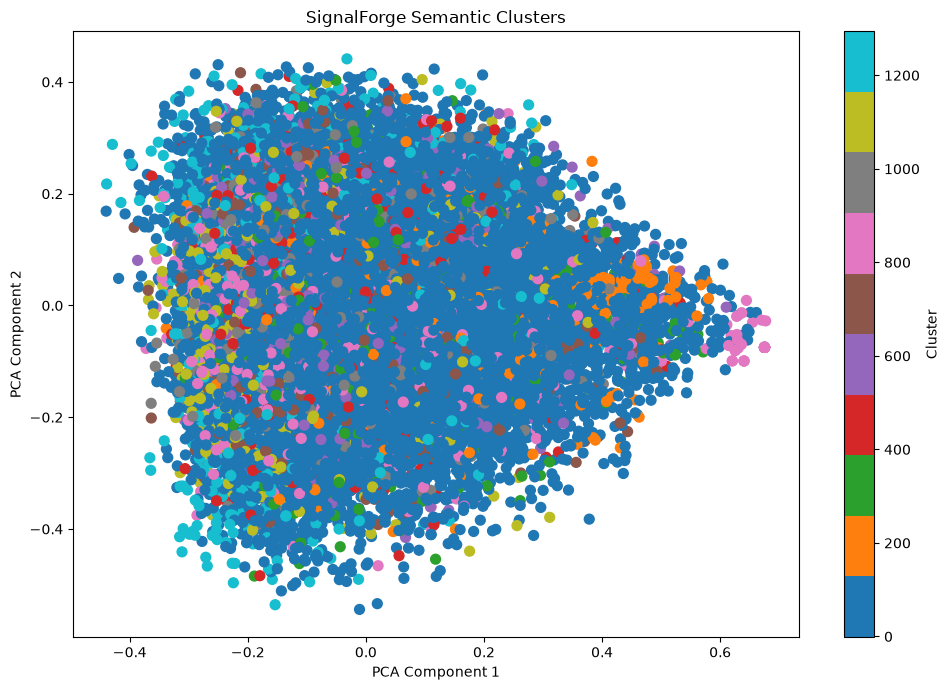

In [8]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SignalForge Semantic Clusters")

plt.colorbar(
    scatter,
    label="Cluster",
)

plt.tight_layout()

plt.show()

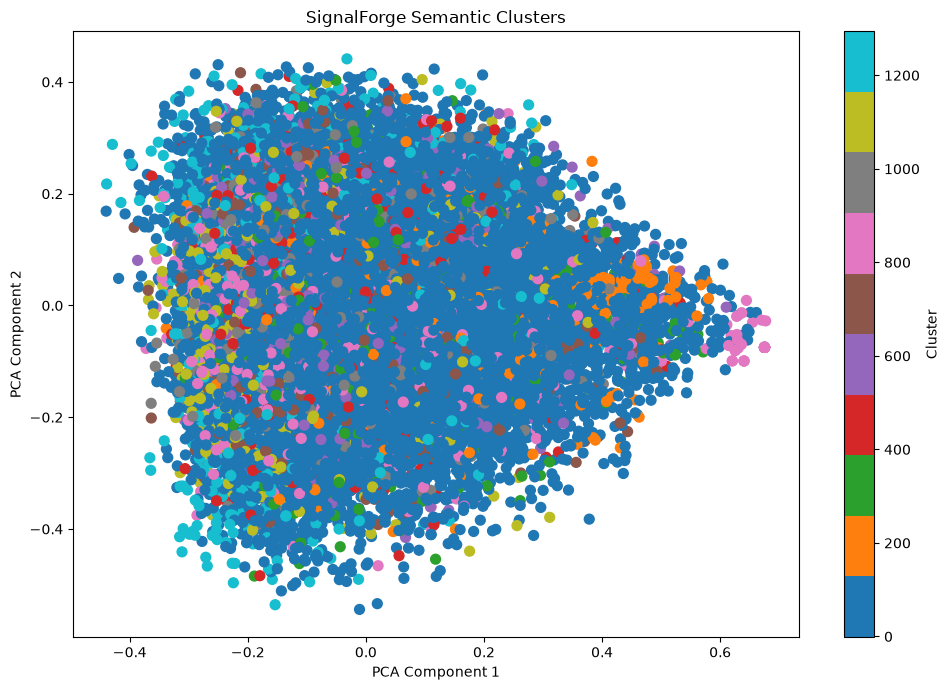

Saved to: /Users/siddharth/Documents/Signal_Forge/outputs/semantic_clusters.png


In [9]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_path = OUTPUT_DIR / "semantic_clusters.png"

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SignalForge Semantic Clusters")

plt.colorbar(
    scatter,
    label="Cluster",
)

plt.tight_layout()

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [10]:
for key, value in result.items():
    print(key, type(value))

posts <class 'list'>
embeddings <class 'numpy.ndarray'>
labels <class 'numpy.ndarray'>
metrics <class 'dict'>
